In [1]:
# =========================================
# 0. INSTALL
# =========================================
!pip install einops seaborn scikit-learn

# =========================================
# 1. IMPORTS
# =========================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from einops import rearrange
from sklearn.metrics import confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

# =========================================
# 2. UTIL
# =========================================
def forward_seq(module, x):
    T,B,C,H,W = x.shape
    x = x.flatten(0,1)
    x = module(x)
    return x.view(T,B,*x.shape[1:])

# =========================================
# 3. SURROGATE
# =========================================
def g_window(x, alpha=0.5):
    return (abs(x) < alpha).float() / (2 * alpha)

class ActFun(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return (input > 1.0).float()

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        return grad_output * g_window(input-1.0)

class ActFunMSF(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        thresholds = torch.arange(4, device=input.device).float()+1
        return sum(input.ge(t).float() for t in thresholds)

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        thresholds = torch.arange(4, device=input.device).float()+1
        grad = sum(g_window(input-t) for t in thresholds)
        return grad_output * grad

# =========================================
# 4. NEURONS
# =========================================

class LIFNeuron(nn.Module):
    def __init__(self):
        super().__init__()
        self.decay = 0.5

    def forward(self, x):
        T = x.size(0)
        mem = torch.zeros_like(x[0])
        out = torch.zeros_like(x)

        self.last_spikes = []
        self.last_mem = None

        for t in range(T):
            reset = (out[t-1] > 0).float() if t > 0 else 0
            mem = mem * self.decay * (1 - reset) + x[t]

            spike = ActFun.apply(mem)
            out[t] = spike

        return out


class MSFNeuron(nn.Module):
    def __init__(self):
        super().__init__()
        self.decay = 0.5

    def forward(self, x):
        T = x.size(0)
        mem = torch.zeros_like(x[0])
        out = torch.zeros_like(x)

        self.last_spikes = []
        self.last_mem = None

        for t in range(T):
            reset = (out[t-1] > 0).float() if t > 0 else 0
            mem = mem * self.decay * (1 - reset) + x[t]

            spike = ActFunMSF.apply(mem)
            out[t] = spike

        return out

# =========================================
# 5. ATTENTION (MEMORY FIXED)
# =========================================
class ChannelAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.conv = nn.Sequential(
            nn.Conv3d(channels, channels//16, 1),  # lighter
            nn.ReLU(),
            nn.Conv3d(channels//16, channels, 1)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x_perm = rearrange(x, "b t c h w -> b c t h w")
        attn = self.sigmoid(self.conv(self.pool(x_perm)))
        return rearrange(attn, "b c 1 1 1 -> b 1 c 1 1")

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2,1,7,padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        x = x.mean(dim=1)   # [B,C,H,W]

        avg = x.mean(1, keepdim=True)
        max,_ = x.max(1, keepdim=True)

        x = torch.cat([avg,max], dim=1)
        x = self.conv(x)

        return self.sigmoid(x).unsqueeze(1)

class CSA(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = rearrange(x, "t b c h w -> b t c h w")
        x = self.ca(x) * x
        x = self.sa(x) * x
        return rearrange(x, "b t c h w -> t b c h w")

# =========================================
# 6. BLOCK
# =========================================
class Block(nn.Module):
    def __init__(self, in_c, out_c, neuron, downsample=False):
        super().__init__()
        self.neuron = neuron()

        self.conv1 = nn.Conv2d(in_c, out_c, 1)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.conv3 = nn.Conv2d(out_c, out_c, 1)

        self.bn1 = nn.BatchNorm2d(out_c)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.bn3 = nn.BatchNorm2d(out_c)

        self.csa = CSA(out_c)
        self.downsample = downsample

        self.shortcut = nn.Conv2d(in_c, out_c, 1) if in_c!=out_c else nn.Identity()

    def forward(self, x):
        identity = forward_seq(self.shortcut, x)

        out = self.neuron(x)
        out = forward_seq(self.conv1, out)
        out = forward_seq(self.bn1, out)

        out = self.neuron(out)
        out = forward_seq(self.conv2, out)
        out = forward_seq(self.bn2, out)

        #
        if self.downsample:
            out = forward_seq(lambda y: F.avg_pool2d(y,2), out)
            identity = forward_seq(lambda y: F.avg_pool2d(y,2), identity)

        out = self.neuron(out)
        out = forward_seq(self.conv3, out)
        out = forward_seq(self.bn3, out)

        out = self.csa(out)
        return out + identity

# =========================================
# 7. MODEL
# =========================================
class MHSANet(nn.Module):
    def __init__(self, neuron, T=4):   # ↓ T
        super().__init__()
        self.T = T

        self.stem = nn.Conv2d(3,48,3,padding=1)

        self.layer1 = Block(48,96, neuron, downsample=True)
        self.layer2 = Block(96,192, neuron, downsample=True)
        self.layer3 = Block(192,192, neuron, downsample=False)

        self.head = neuron()
        self.fc = nn.Linear(192,10)

    def forward(self, x):
        x = x.unsqueeze(0).repeat(self.T,1,1,1,1)

        x = forward_seq(self.stem, x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.head(x)

        x = x.mean([3,4])
        x = x.mean(0)

        return self.fc(x)

# =========================================
# 8. DATA (UNCHANGED)
# =========================================
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),
                         (0.2470,0.2435,0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),
                         (0.2470,0.2435,0.2616))
])

trainset = torchvision.datasets.CIFAR10('./data',train=True,download=True,transform=transform_train)
testset  = torchvision.datasets.CIFAR10('./data',train=False,download=True,transform=transform_test)

trainloader = DataLoader(trainset, batch_size=32, shuffle=True,
                         num_workers=2, pin_memory=True, persistent_workers=True)

testloader  = DataLoader(testset, batch_size=32, shuffle=False,
                         num_workers=2, pin_memory=True, persistent_workers=True)

# =========================================
# 9. TRAIN
# =========================================

def train_model(model, epochs=40):
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.05)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)

    scaler = torch.cuda.amp.GradScaler()

    train_accs, test_accs = [], []
    all_preds, all_labels = [], []

    for epoch in range(epochs):
        model.train()
        correct,total = 0,0

        for x,y in trainloader:
            x,y = x.to(device), y.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                out = model(x)
                loss = F.cross_entropy(out,y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            pred = out.argmax(1)
            correct += (pred==y).sum().item()
            total += y.size(0)

        train_acc = 100*correct/total

        # TEST
        model.eval()
        correct,total = 0,0
        all_preds.clear()
        all_labels.clear()

        with torch.no_grad():
            for x,y in testloader:
                x,y = x.to(device), y.to(device)
                out = model(x)
                pred = out.argmax(1)

                correct += (pred==y).sum().item()
                total += y.size(0)

                all_preds.extend(pred.cpu().numpy())
                all_labels.extend(y.cpu().numpy())

        test_acc = 100*correct/total

        train_accs.append(train_acc)
        test_accs.append(test_acc)

        scheduler.step()

        print(f"Epoch {epoch+1}: Train {train_acc:.2f} | Test {test_acc:.2f}")
        if (epoch+1) % 5 == 0:
            torch.save(model.state_dict(), f"checkpoint_epoch_{epoch+1}.pth")
    return train_accs, test_accs, all_preds, all_labels
# =========================================
# 10. RUN
# =========================================
print(" MSF Training")
msf_model = MHSANet(MSFNeuron).to(device)
msf_train, msf_test, msf_preds, labels = train_model(msf_model)



100%|██████████| 170M/170M [00:03<00:00, 48.8MB/s]


 MSF Training


/tmp/ipykernel_2952/541139638.py:273: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_2952/541139638.py:287: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1: Train 43.92 | Test 53.14
Epoch 2: Train 59.67 | Test 63.54
Epoch 3: Train 65.77 | Test 67.86
Epoch 4: Train 69.89 | Test 71.43
Epoch 5: Train 73.10 | Test 73.86
Epoch 6: Train 76.10 | Test 76.94
Epoch 7: Train 77.57 | Test 77.68
Epoch 8: Train 79.16 | Test 78.92
Epoch 9: Train 80.20 | Test 78.89
Epoch 10: Train 81.12 | Test 80.20
Epoch 11: Train 81.82 | Test 81.01
Epoch 12: Train 82.69 | Test 81.56
Epoch 13: Train 83.34 | Test 81.92
Epoch 14: Train 84.02 | Test 83.23
Epoch 15: Train 84.61 | Test 83.53
Epoch 16: Train 85.05 | Test 82.13
Epoch 17: Train 85.40 | Test 83.65
Epoch 18: Train 85.96 | Test 84.04
Epoch 19: Train 86.13 | Test 84.01
Epoch 20: Train 86.83 | Test 84.47
Epoch 21: Train 87.21 | Test 83.98
Epoch 22: Train 87.64 | Test 84.91
Epoch 23: Train 87.93 | Test 85.46
Epoch 24: Train 88.23 | Test 85.79
Epoch 25: Train 88.81 | Test 85.52
Epoch 26: Train 89.13 | Test 85.88
Epoch 27: Train 89.44 | Test 85.97
Epoch 28: Train 89.71 | Test 86.35
Epoch 29: Train 90.17 | Test 

In [2]:
print(" LIF Training")
lif_model = MHSANet(LIFNeuron).to(device)
lif_train, lif_test, lif_preds, _ = train_model(lif_model)

 LIF Training


/tmp/ipykernel_2952/541139638.py:273: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_2952/541139638.py:287: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1: Train 40.50 | Test 49.50
Epoch 2: Train 55.04 | Test 59.47
Epoch 3: Train 61.52 | Test 64.95
Epoch 4: Train 65.16 | Test 67.29
Epoch 5: Train 68.02 | Test 69.73
Epoch 6: Train 70.25 | Test 71.27
Epoch 7: Train 71.77 | Test 72.71
Epoch 8: Train 73.23 | Test 74.22
Epoch 9: Train 74.33 | Test 75.48
Epoch 10: Train 75.49 | Test 75.83
Epoch 11: Train 76.82 | Test 75.74
Epoch 12: Train 77.69 | Test 77.36
Epoch 13: Train 78.21 | Test 78.34
Epoch 14: Train 79.13 | Test 78.76
Epoch 15: Train 80.08 | Test 78.92
Epoch 16: Train 80.64 | Test 79.95
Epoch 17: Train 81.21 | Test 80.60
Epoch 18: Train 81.62 | Test 80.08
Epoch 19: Train 82.27 | Test 79.65
Epoch 20: Train 82.81 | Test 81.67
Epoch 21: Train 83.27 | Test 81.51
Epoch 22: Train 83.70 | Test 82.08
Epoch 23: Train 84.11 | Test 82.33
Epoch 24: Train 84.71 | Test 82.54
Epoch 25: Train 85.24 | Test 83.17
Epoch 26: Train 85.42 | Test 83.38
Epoch 27: Train 85.74 | Test 83.12
Epoch 28: Train 86.28 | Test 83.72
Epoch 29: Train 86.51 | Test 

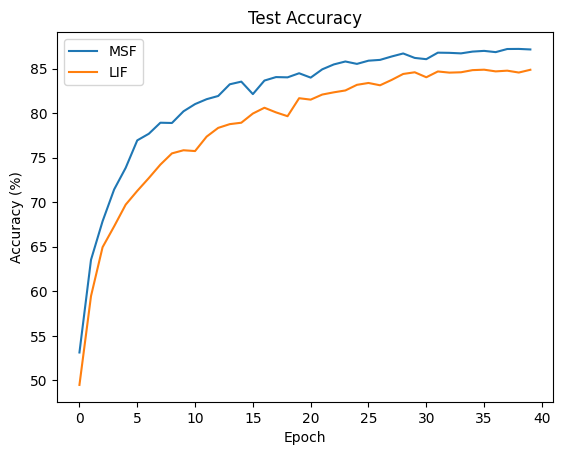

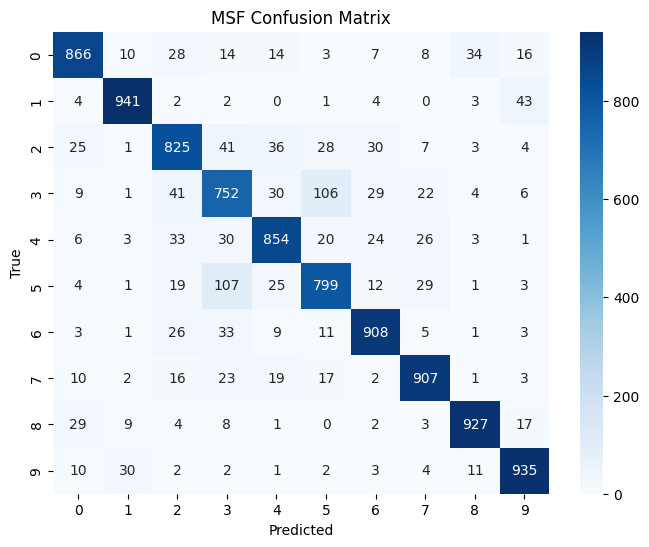

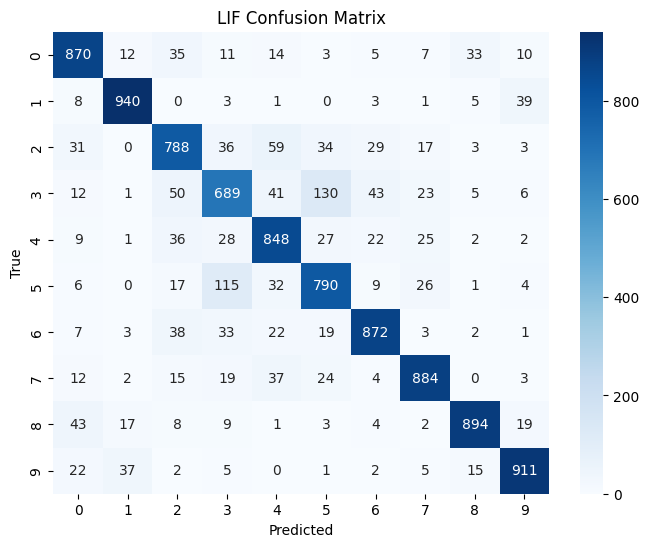

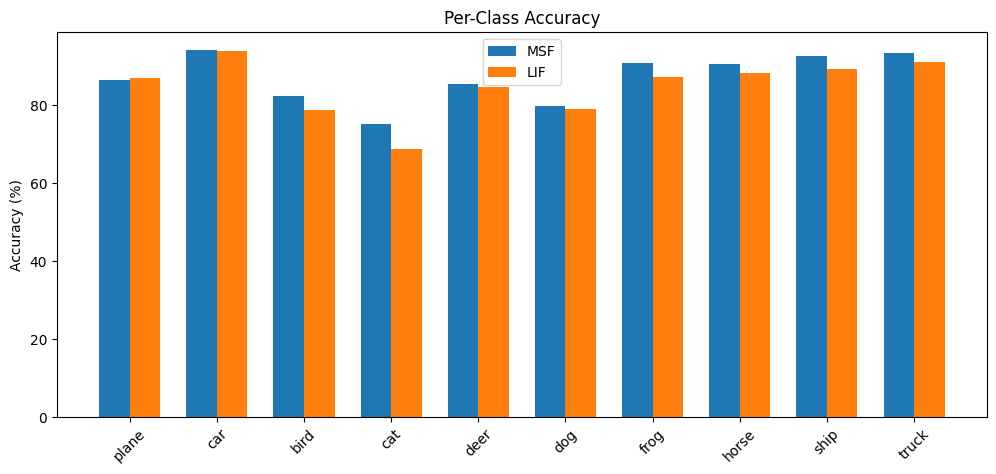

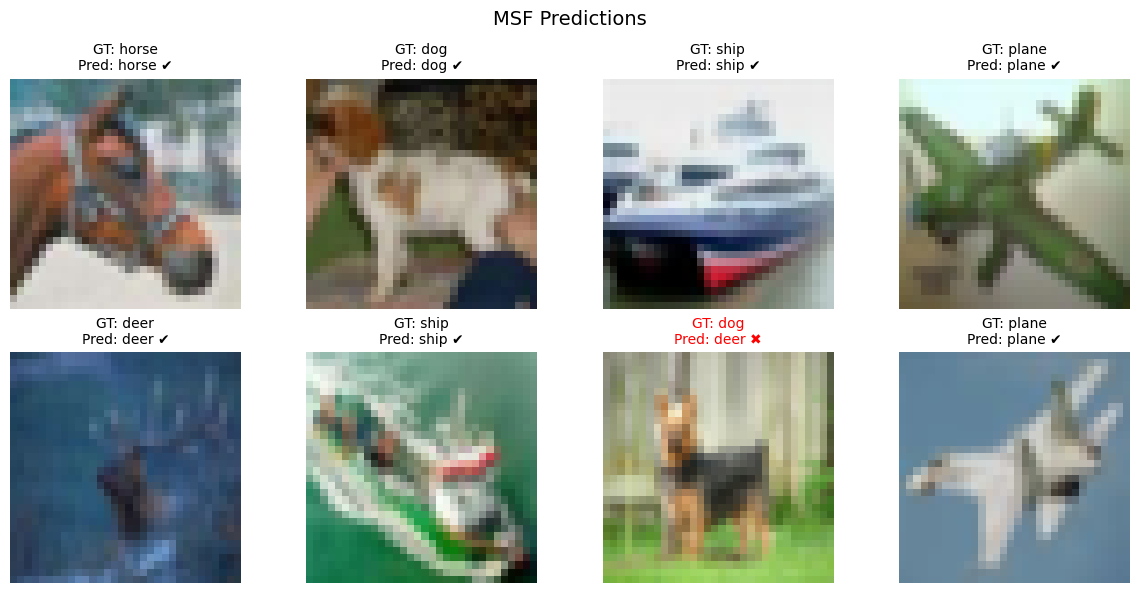

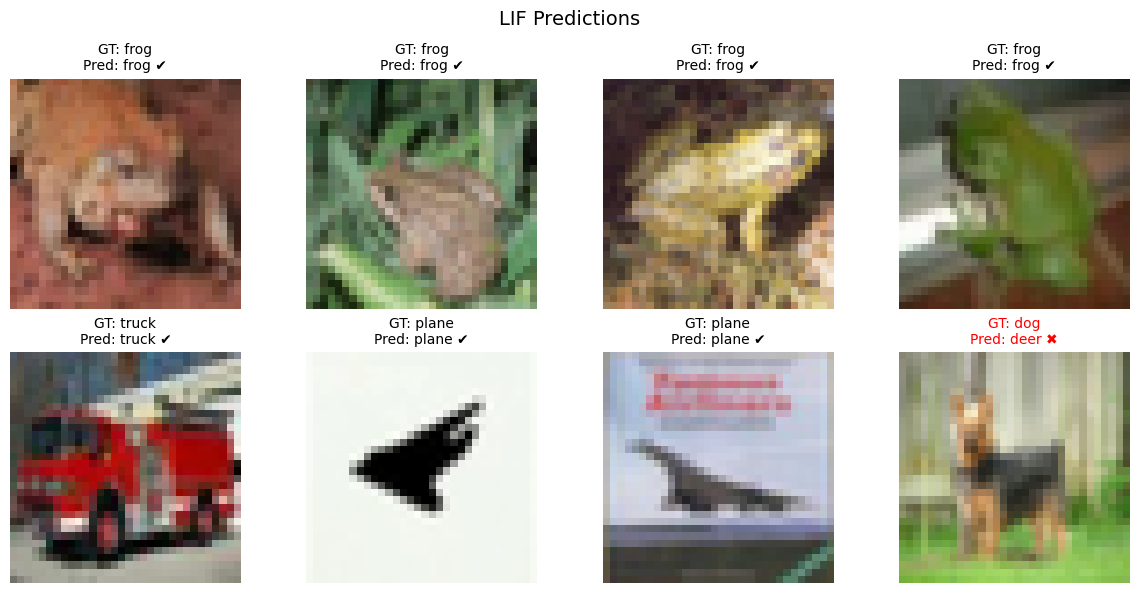

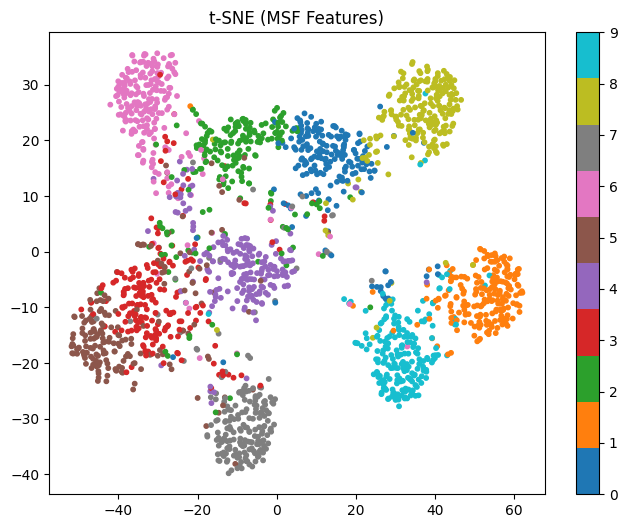

In [3]:
# =========================================
# 11. VISUALIZATION
# =========================================

# -------------------------
# Accuracy
# -------------------------
plt.figure()
plt.plot(msf_test, label="MSF")
plt.plot(lif_test, label="LIF")
plt.legend()
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.show()


# -------------------------
# Confusion Matrix (MSF + LIF)
# -------------------------
def plot_confusion(preds, labels, title):
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

plot_confusion(msf_preds, labels, "MSF Confusion Matrix")
plot_confusion(lif_preds, labels, "LIF Confusion Matrix")


# -------------------------
# Per-Class Accuracy
# -------------------------
def per_class_accuracy(preds, labels, num_classes=10):
    correct = [0]*num_classes
    total = [0]*num_classes

    for p, l in zip(preds, labels):
        total[l] += 1
        if p == l:
            correct[l] += 1

    return [100*c/t if t>0 else 0 for c,t in zip(correct,total)]

classes = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']

msf_class_acc = per_class_accuracy(msf_preds, labels)
lif_class_acc = per_class_accuracy(lif_preds, labels)

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(12,5))
plt.bar(x - width/2, msf_class_acc, width, label='MSF')
plt.bar(x + width/2, lif_class_acc, width, label='LIF')

plt.xticks(x, classes, rotation=45)
plt.ylabel("Accuracy (%)")
plt.title("Per-Class Accuracy")
plt.legend()
plt.show()


# -------------------------
# Predictions Visualization
# -------------------------
import random

def denormalize(img):
    mean = np.array([0.4914,0.4822,0.4465])
    std  = np.array([0.2470,0.2435,0.2616])
    return np.clip(img*std + mean, 0, 1)

def show_predictions(model, loader, title):
    model.eval()
    images, labels_ = next(iter(loader))
    images, labels_ = images.to(device), labels_.to(device)

    with torch.no_grad():
        outputs = model(images)
        preds = outputs.argmax(1)

    images = images.cpu().numpy()
    preds = preds.cpu().numpy()
    labels_ = labels_.cpu().numpy()

    plt.figure(figsize=(12,6))
    plt.suptitle(title, fontsize=14)

    for i in range(8):
        idx = random.randint(0, len(images)-1)

        img = np.transpose(images[idx], (1,2,0))
        img = denormalize(img)

        plt.subplot(2,4,i+1)


        plt.imshow(np.kron(img, np.ones((4,4,1))), interpolation='nearest')

        text = f"GT: {classes[labels_[idx]]}\nPred: {classes[preds[idx]]}"
        if preds[idx] == labels_[idx]:
            plt.title(text + " ✔", fontsize=10)
        else:
            plt.title(text + " ✖", color='red', fontsize=10)

        plt.axis('off')

    plt.tight_layout()
    plt.show()

show_predictions(msf_model, testloader, "MSF Predictions")
show_predictions(lif_model, testloader, "LIF Predictions")


# -------------------------
# t-SNE
# -------------------------
from sklearn.manifold import TSNE

def extract_features(model, loader, max_samples=2000):
    model.eval()
    feats = []
    labels_ = []

    with torch.no_grad():
        for x,y in loader:
            x = x.to(device)
            out = model(x)

            feats.append(out.cpu())
            labels_.append(y)

            if len(feats)*x.size(0) > max_samples:
                break

    return torch.cat(feats).numpy(), torch.cat(labels_).numpy()

msf_feats, msf_labels = extract_features(msf_model, testloader)

tsne = TSNE(n_components=2, perplexity=30)
emb = tsne.fit_transform(msf_feats)

plt.figure(figsize=(8,6))
plt.scatter(emb[:,0], emb[:,1], c=msf_labels, cmap='tab10', s=10)
plt.title("t-SNE (MSF Features)")
plt.colorbar()
plt.show()